In [2]:
import mysql.connector
import pandas as pd
conn = mysql.connector.connect(
    host = "localhost",
    user = "root",
    password = "Angel*1153",
    database = "myproject"
)

In [3]:
query = """SELECT l.*, p.*, pr.*, c.* FROM loan l JOIN payment p ON l.ID = p.ID
         JOIN property pr ON l.Loan_ID = pr.Property_ID JOIN customer c ON l.ID = c.ID"""
df = pd.read_sql(query,conn)
df.head()

C:\Users\Anjali\AppData\Local\Temp\ipykernel_15476\255229123.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


,ID,loan_amount,loan_type,loan_purpose,loan_limit,term,rate_of_interest,Interest_rate_spread,Upfront_charges,LTV,...,business_or_commercial,Property_ID,ID,age,income,Gender,Region,credit_type,Credit_Score,co-applicant_credit_type
0,24890,116500,type1,p1,cf,360.0,,,,98.72881356,...,nob/c,1,24890,25-34,1740.0,Sex Not Available,south,EXP,758,CIB
1,24891,206500,type2,p1,cf,360.0,,,,,...,b/c,2,24891,55-64,4980.0,Male,North,EQUI,552,EXP
2,24892,406500,type1,p1,cf,360.0,4.56,0.2,595.0,80.01968504,...,nob/c,3,24892,35-44,9480.0,Male,south,EXP,834,CIB
3,24893,456500,type1,p4,cf,360.0,4.25,0.681,,69.3768997,...,nob/c,4,24893,45-54,11880.0,Male,North,EXP,587,CIB
4,24894,696500,type1,p1,cf,360.0,4.0,0.3042,0.0,91.88654354,...,nob/c,5,24894,25-34,10440.0,Joint,North,CRIF,602,EXP


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.impute import SimpleImputer

In [4]:
df.shape

(139479, 33)

In [5]:
df.columns

Index(['ID', 'loan_amount', 'loan_type', 'loan_purpose', 'loan_limit', 'term',
       'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'LTV',
       'dtir1', 'Status', 'Loan_ID', 'ID', 'Payment_ID', 'Delay_Days',
       'Payment_Status', 'property_value', 'construction_type',
       'occupancy_type', 'Secured_by', 'total_units', 'Security_Type',
       'business_or_commercial', 'Property_ID', 'ID', 'age', 'income',
       'Gender', 'Region', 'credit_type', 'Credit_Score',
       'co-applicant_credit_type'],
      dtype='str')

In [6]:
df.describe()

,ID,loan_amount,term,Status,Loan_ID,ID,Payment_ID,Delay_Days,Property_ID,ID,income,Credit_Score
count,139479.000000,1.394790e+05,139479.000000,139479.000000,139479.000000,139479.000000,139479.000000,139479.000000,139479.000000,139479.000000,139479.000000,139479.000000
mean,99180.635271,3.290183e+05,333.775658,0.253694,74291.635271,99180.635271,74291.635271,59.398598,74291.635271,99180.635271,6956.984922,699.876376
std,42927.119401,1.845141e+05,59.783367,0.435126,42927.119401,42927.119401,42927.119401,34.683864,42927.119401,42927.119401,6496.119920,115.833379
min,24890.000000,1.650000e+04,96.000000,0.000000,1.000000,24890.000000,1.000000,0.000000,1.000000,24890.000000,0.000000,500.000000
25%,61968.500000,1.965000e+05,360.000000,0.000000,37079.500000,61968.500000,37079.500000,29.000000,37079.500000,61968.500000,3720.000000,600.000000
50%,99137.000000,2.965000e+05,360.000000,0.000000,74248.000000,99137.000000,74248.000000,59.000000,74248.000000,99137.000000,5760.000000,699.000000
75%,136354.500000,4.365000e+05,360.000000,1.000000,111465.500000,136354.500000,111465.500000,89.000000,111465.500000,136354.500000,8520.000000,800.000000
max,173559.000000,3.576500e+06,360.000000,1.000000,148670.000000,173559.000000,148670.000000,119.000000,148670.000000,173559.000000,578580.000000,900.000000


In [7]:
df.drop(columns=['ID','Loan_ID','ID','Payment_ID','Property_ID','ID',],inplace=True)

In [8]:
df.shape

(139479, 27)

In [9]:
df.isnull().sum()

loan_amount                 0
loan_type                   0
loan_purpose                0
loan_limit                  0
term                        0
rate_of_interest            0
Interest_rate_spread        0
Upfront_charges             0
LTV                         0
dtir1                       0
Status                      0
Delay_Days                  0
Payment_Status              0
property_value              0
construction_type           0
occupancy_type              0
Secured_by                  0
total_units                 0
Security_Type               0
business_or_commercial      0
age                         0
income                      0
Gender                      0
Region                      0
credit_type                 0
Credit_Score                0
co-applicant_credit_type    0
dtype: int64

In [10]:
df.replace([ '', ' '],np.nan,inplace=True)

,loan_amount,loan_type,loan_purpose,loan_limit,term,rate_of_interest,Interest_rate_spread,Upfront_charges,LTV,dtir1,...,total_units,Security_Type,business_or_commercial,age,income,Gender,Region,credit_type,Credit_Score,co-applicant_credit_type
0,116500,type1,p1,cf,360.0,NaN,NaN,NaN,98.72881356,45.0,...,1U,direct,nob/c,25-34,1740.0,Sex Not Available,south,EXP,758,CIB
1,206500,type2,p1,cf,360.0,NaN,NaN,NaN,NaN,NaN,...,1U,direct,b/c,55-64,4980.0,Male,North,EQUI,552,EXP
2,406500,type1,p1,cf,360.0,4.56,0.2,595.0,80.01968504,46.0,...,1U,direct,nob/c,35-44,9480.0,Male,south,EXP,834,CIB
3,456500,type1,p4,cf,360.0,4.25,0.681,NaN,69.3768997,42.0,...,1U,direct,nob/c,45-54,11880.0,Male,North,EXP,587,CIB
4,696500,type1,p1,cf,360.0,4.0,0.3042,0.0,91.88654354,39.0,...,1U,direct,nob/c,25-34,10440.0,Joint,North,CRIF,602,EXP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139474,706500,type1,p4,ncf,360.0,3.875,-0.1044,878.36,79.56081081,36.0,...,1U,direct,nob/c,45-54,9840.0,Joint,North,EXP,676,EXP
139475,296500,type1,p3,cf,180.0,3.75,0.4206,5566.3,72.67156863,38.0,...,1U,direct,nob/c,35-44,4860.0,Male,central,CRIF,758,CIB
139476,196500,type1,p3,cf,180.0,3.99,0.9888,3304.69,68.22916667,29.0,...,1U,direct,nob/c,45-54,8340.0,Male,North,EXP,747,CIB
139477,286500,type1,p4,cf,360.0,3.99,0.524,3256.88,80.02793296,40.0,...,1U,direct,nob/c,45-54,3420.0,Male,North,CIB,755,CIB


In [11]:
df.isna().sum()

loan_amount                     0
loan_type                       0
loan_purpose                  126
loan_limit                   3248
term                            0
rate_of_interest            35385
Interest_rate_spread        35385
Upfront_charges             38170
LTV                         15071
dtir1                       15069
Status                          0
Delay_Days                      0
Payment_Status                  0
property_value              15071
construction_type               0
occupancy_type                  0
Secured_by                      0
total_units                     0
Security_Type                   0
business_or_commercial          0
age                             0
income                          0
Gender                          0
Region                          0
credit_type                     0
Credit_Score                    0
co-applicant_credit_type        0
dtype: int64

In [12]:
df.dtypes

loan_amount                   int64
loan_type                       str
loan_purpose                    str
loan_limit                      str
term                        float64
rate_of_interest                str
Interest_rate_spread            str
Upfront_charges                 str
LTV                             str
dtir1                           str
Status                        int64
Delay_Days                    int64
Payment_Status                  str
property_value                  str
construction_type               str
occupancy_type                  str
Secured_by                      str
total_units                     str
Security_Type                   str
business_or_commercial          str
age                             str
income                      float64
Gender                          str
Region                          str
credit_type                     str
Credit_Score                  int64
co-applicant_credit_type        str
dtype: object

In [13]:
df[['rate_of_interest','Interest_rate_spread','Upfront_charges','dtir1','property_value']] = df[['rate_of_interest','Interest_rate_spread','Upfront_charges','dtir1','property_value']].astype(float) 

In [14]:
df.dtypes

loan_amount                   int64
loan_type                       str
loan_purpose                    str
loan_limit                      str
term                        float64
rate_of_interest            float64
Interest_rate_spread        float64
Upfront_charges             float64
LTV                             str
dtir1                       float64
Status                        int64
Delay_Days                    int64
Payment_Status                  str
property_value              float64
construction_type               str
occupancy_type                  str
Secured_by                      str
total_units                     str
Security_Type                   str
business_or_commercial          str
age                             str
income                      float64
Gender                          str
Region                          str
credit_type                     str
Credit_Score                  int64
co-applicant_credit_type        str
dtype: object

In [15]:
(df.isna().sum() / len(df)) * 100

loan_amount                  0.000000
loan_type                    0.000000
loan_purpose                 0.090336
loan_limit                   2.328666
term                         0.000000
rate_of_interest            25.369410
Interest_rate_spread        25.369410
Upfront_charges             27.366127
LTV                         10.805211
dtir1                       10.803777
Status                       0.000000
Delay_Days                   0.000000
Payment_Status               0.000000
property_value              10.805211
construction_type            0.000000
occupancy_type               0.000000
Secured_by                   0.000000
total_units                  0.000000
Security_Type                0.000000
business_or_commercial       0.000000
age                          0.000000
income                       0.000000
Gender                       0.000000
Region                       0.000000
credit_type                  0.000000
Credit_Score                 0.000000
co-applicant

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.dropna(subset=['loan_limit'],inplace= True)
df.dropna(subset=['loan_purpose'],inplace= True)

In [18]:
imputer = SimpleImputer(strategy='mean')
df[['rate_of_interest','Interest_rate_spread','Upfront_charges','LTV','dtir1','property_value']] = imputer.fit_transform(df[['rate_of_interest','Interest_rate_spread','Upfront_charges','LTV','dtir1','property_value']])
df

,loan_amount,loan_type,loan_purpose,loan_limit,term,rate_of_interest,Interest_rate_spread,Upfront_charges,LTV,dtir1,...,total_units,Security_Type,business_or_commercial,age,income,Gender,Region,credit_type,Credit_Score,co-applicant_credit_type
0,116500,type1,p1,cf,360.0,4.087372,0.469668,3388.512767,98.728814,45.000000,...,1U,direct,nob/c,25-34,1740.0,Sex Not Available,south,EXP,758,CIB
1,206500,type2,p1,cf,360.0,4.087372,0.469668,3388.512767,71.465484,37.724782,...,1U,direct,b/c,55-64,4980.0,Male,North,EQUI,552,EXP
2,406500,type1,p1,cf,360.0,4.560000,0.200000,595.000000,80.019685,46.000000,...,1U,direct,nob/c,35-44,9480.0,Male,south,EXP,834,CIB
3,456500,type1,p4,cf,360.0,4.250000,0.681000,3388.512767,69.376900,42.000000,...,1U,direct,nob/c,45-54,11880.0,Male,North,EXP,587,CIB
4,696500,type1,p1,cf,360.0,4.000000,0.304200,0.000000,91.886544,39.000000,...,1U,direct,nob/c,25-34,10440.0,Joint,North,CRIF,602,EXP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139474,706500,type1,p4,ncf,360.0,3.875000,-0.104400,878.360000,79.560811,36.000000,...,1U,direct,nob/c,45-54,9840.0,Joint,North,EXP,676,EXP
139475,296500,type1,p3,cf,180.0,3.750000,0.420600,5566.300000,72.671569,38.000000,...,1U,direct,nob/c,35-44,4860.0,Male,central,CRIF,758,CIB
139476,196500,type1,p3,cf,180.0,3.990000,0.988800,3304.690000,68.229167,29.000000,...,1U,direct,nob/c,45-54,8340.0,Male,North,EXP,747,CIB
139477,286500,type1,p4,cf,360.0,3.990000,0.524000,3256.880000,80.027933,40.000000,...,1U,direct,nob/c,45-54,3420.0,Male,North,CIB,755,CIB


In [19]:
df.isna().sum()

loan_amount                 0
loan_type                   0
loan_purpose                0
loan_limit                  0
term                        0
rate_of_interest            0
Interest_rate_spread        0
Upfront_charges             0
LTV                         0
dtir1                       0
Status                      0
Delay_Days                  0
Payment_Status              0
property_value              0
construction_type           0
occupancy_type              0
Secured_by                  0
total_units                 0
Security_Type               0
business_or_commercial      0
age                         0
income                      0
Gender                      0
Region                      0
credit_type                 0
Credit_Score                0
co-applicant_credit_type    0
dtype: int64

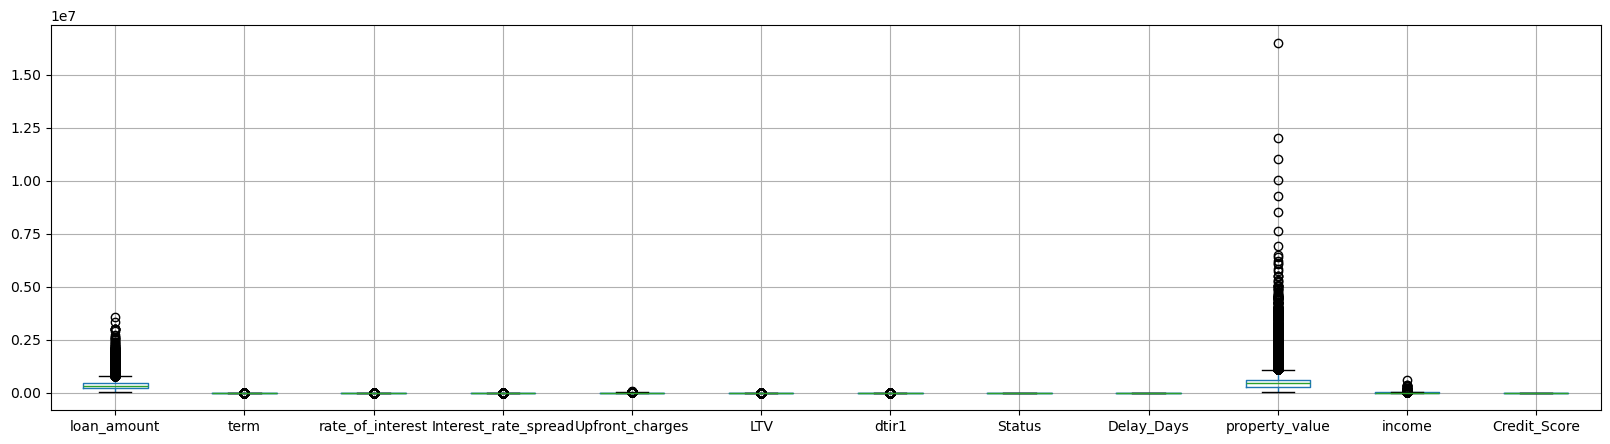

In [20]:
plt.figure(figsize = (20,5))
df.boxplot()
plt.show()

In [21]:
df['total_units'] = df['total_units'].str.replace('U', '')

In [22]:
df['total_units']

0         1
1         1
2         1
3         1
4         1
         ..
139474    1
139475    1
139476    1
139477    1
139478    1
Name: total_units, Length: 136105, dtype: str

In [23]:
df.dtypes

loan_amount                   int64
loan_type                       str
loan_purpose                    str
loan_limit                      str
term                        float64
rate_of_interest            float64
Interest_rate_spread        float64
Upfront_charges             float64
LTV                         float64
dtir1                       float64
Status                        int64
Delay_Days                    int64
Payment_Status                  str
property_value              float64
construction_type               str
occupancy_type                  str
Secured_by                      str
total_units                     str
Security_Type                   str
business_or_commercial          str
age                             str
income                      float64
Gender                          str
Region                          str
credit_type                     str
Credit_Score                  int64
co-applicant_credit_type        str
dtype: object

In [24]:
df['total_units'] = df['total_units'].str.strip().astype(int)

In [25]:
df['total_units'].dtypes

dtype('int64')

In [26]:
df['loan_purpose'].head()

0    p1
1    p1
2    p1
3    p4
4    p1
Name: loan_purpose, dtype: str

In [27]:
df['loan_purpose'] = df['loan_purpose'].str.replace('p', '')

In [28]:
df['loan_purpose']

0         1
1         1
2         1
3         4
4         1
         ..
139474    4
139475    3
139476    3
139477    4
139478    3
Name: loan_purpose, Length: 136105, dtype: str

In [29]:
df['loan_purpose'].dtypes

<StringDtype(na_value=nan)>

In [30]:
df['loan_purpose'] = df['loan_purpose'].astype(int)

In [31]:
df['loan_purpose'].dtypes

dtype('int64')

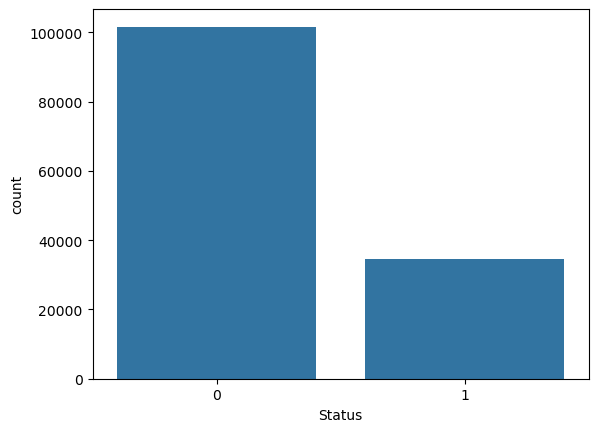

In [32]:
sns.countplot(x= df['Status'])
plt.show()

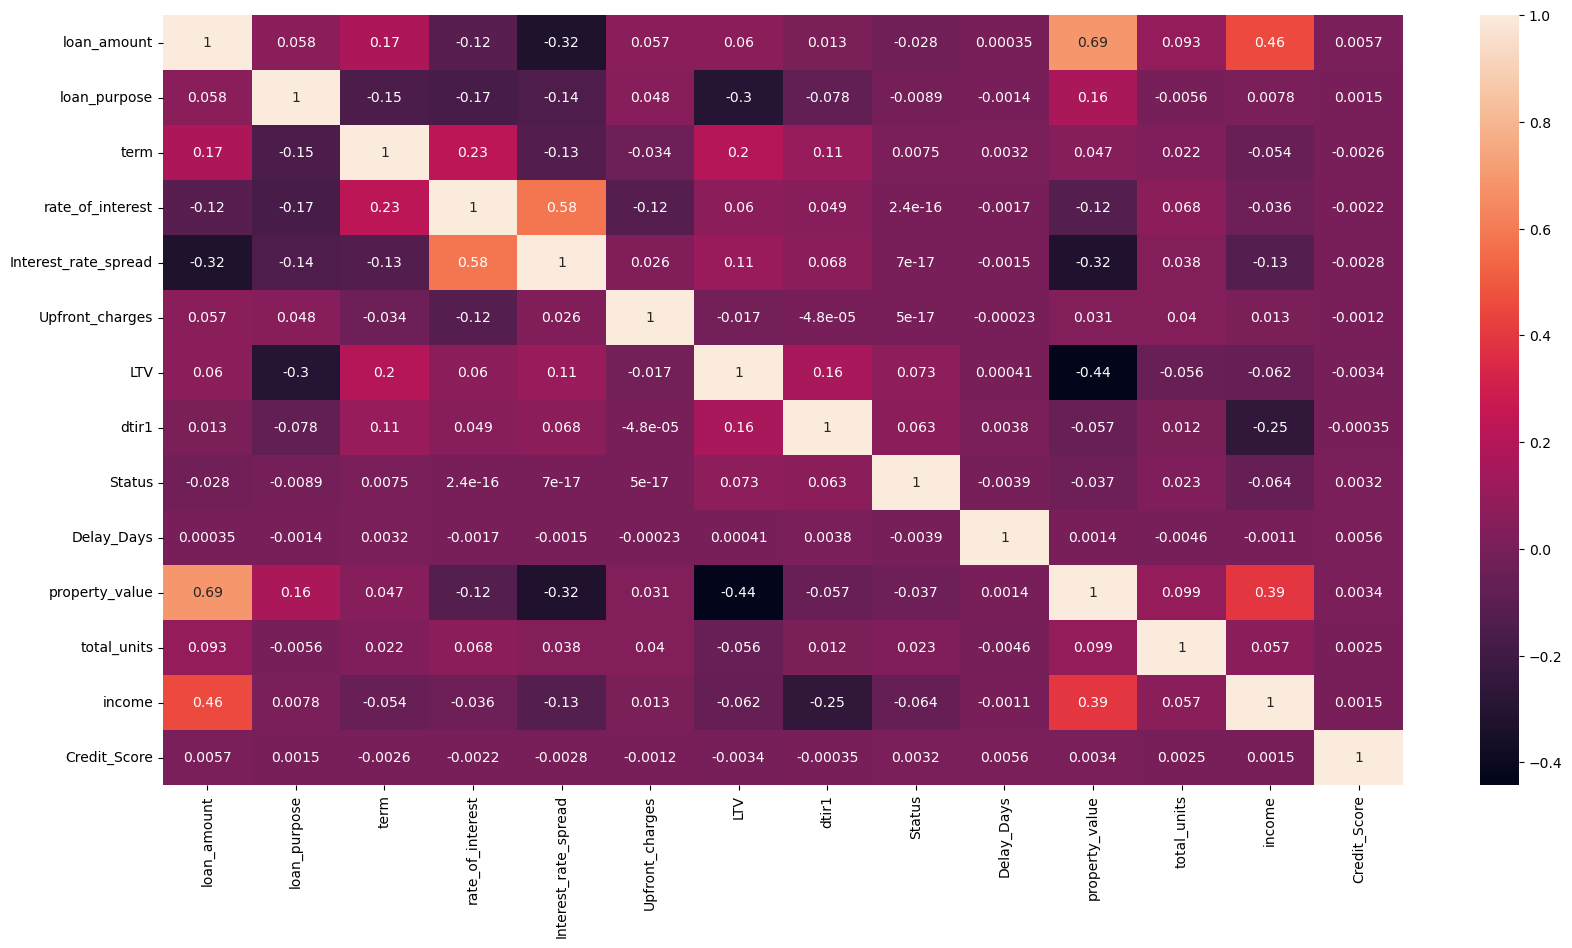

In [33]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [34]:
text_cols = df.select_dtypes(object)
text_cols.head()

,loan_type,loan_limit,Payment_Status,construction_type,occupancy_type,Secured_by,Security_Type,business_or_commercial,age,Gender,Region,credit_type,co-applicant_credit_type
0,type1,cf,Late,sb,pr,home,direct,nob/c,25-34,Sex Not Available,south,EXP,CIB
1,type2,cf,Late,sb,pr,home,direct,b/c,55-64,Male,North,EQUI,EXP
2,type1,cf,Late,sb,pr,home,direct,nob/c,35-44,Male,south,EXP,CIB
3,type1,cf,Late,sb,pr,home,direct,nob/c,45-54,Male,North,EXP,CIB
4,type1,cf,Late,sb,pr,home,direct,nob/c,25-34,Joint,North,CRIF,EXP


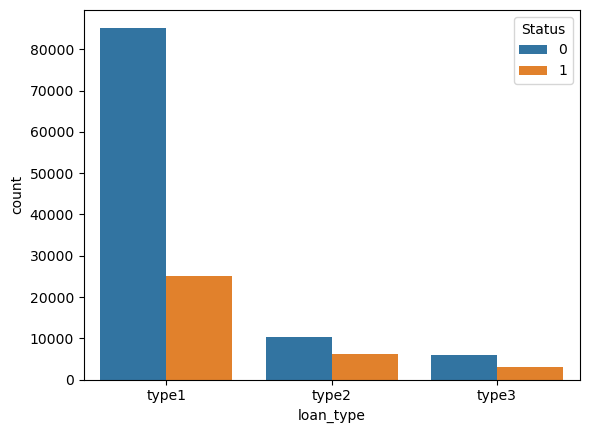

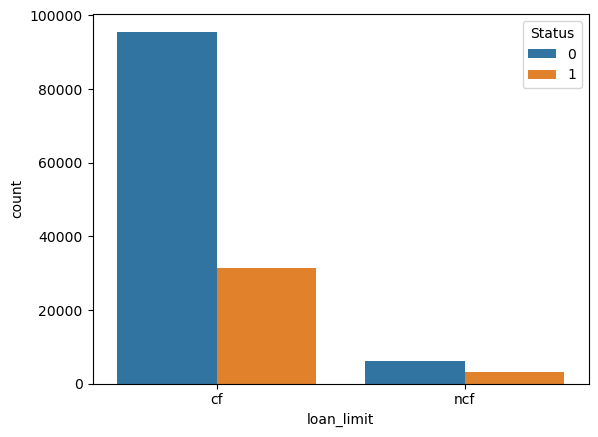

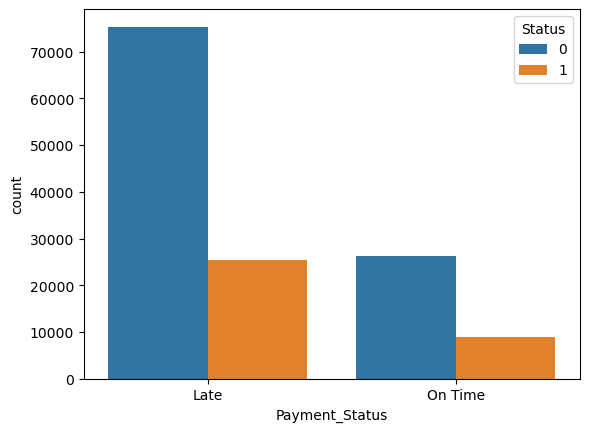

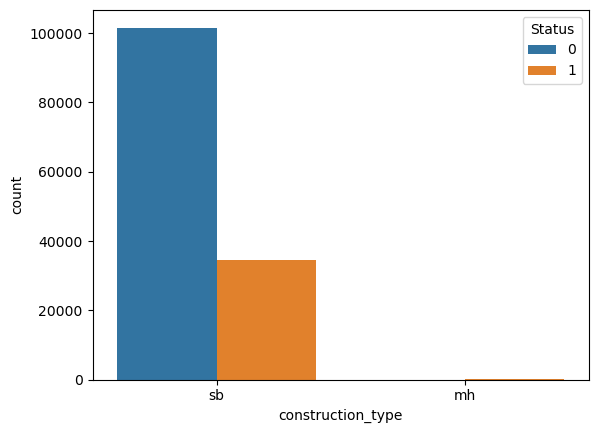

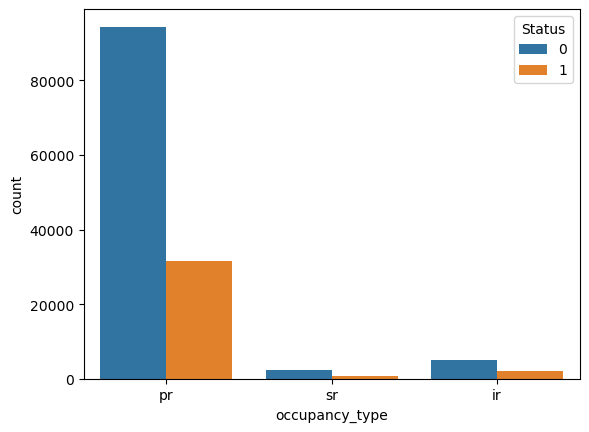

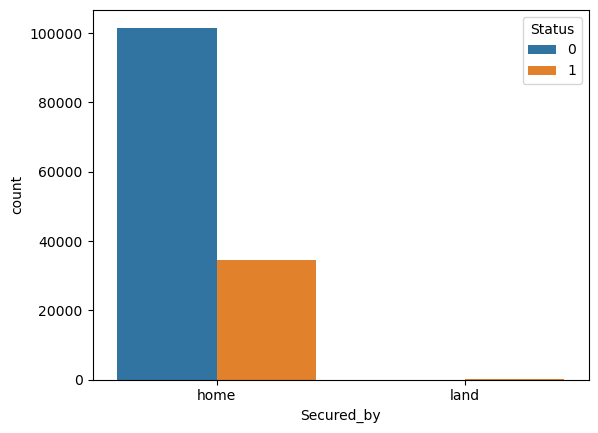

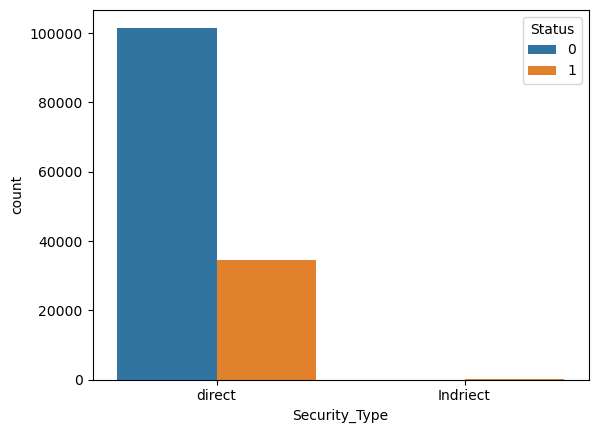

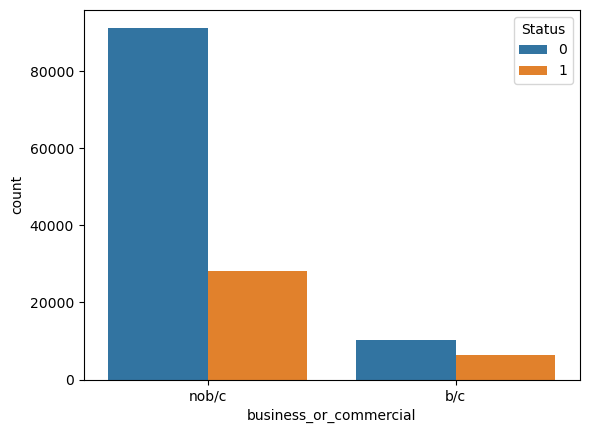

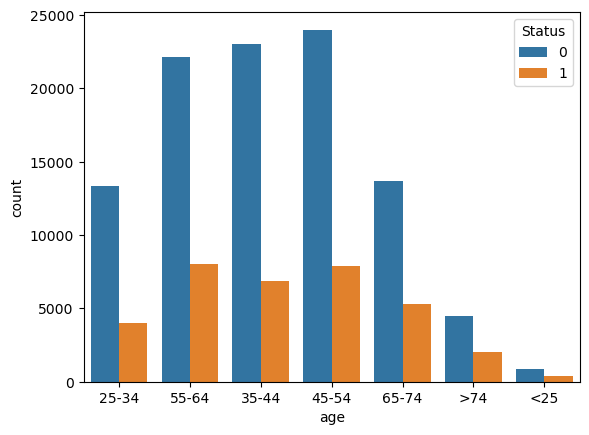

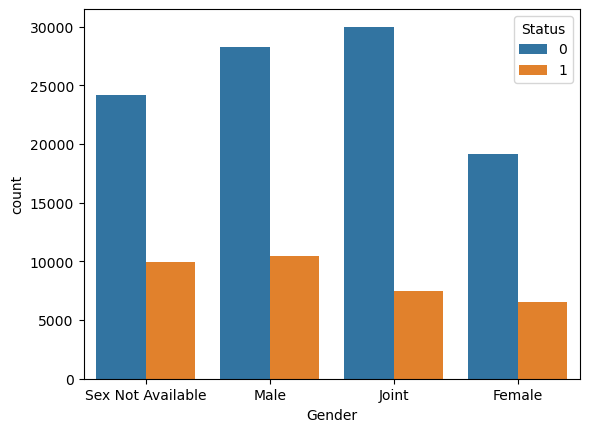

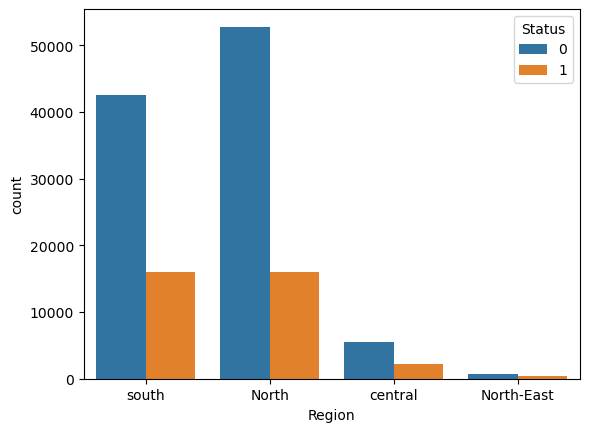

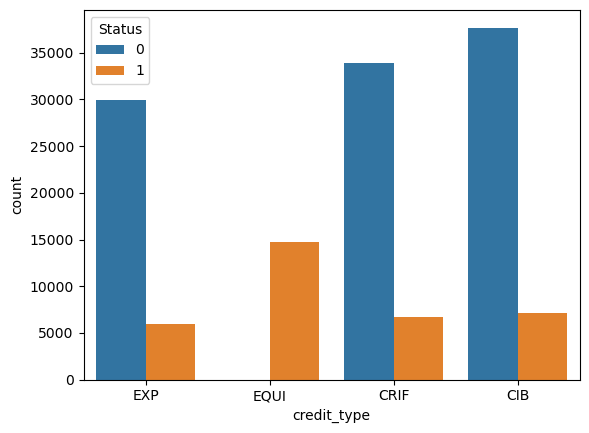

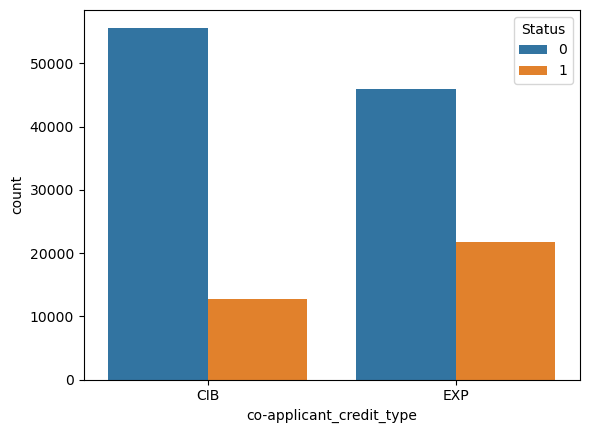

In [35]:
for i in text_cols.columns:
    sns.countplot(x = text_cols[i],hue = df['Status'])
    plt.show()

In [36]:
num_cols = df.select_dtypes([int,float])

In [37]:
num_cols.head()

,loan_amount,loan_purpose,term,rate_of_interest,Interest_rate_spread,Upfront_charges,LTV,dtir1,Status,Delay_Days,property_value,total_units,income,Credit_Score
0,116500,1,360.0,4.087372,0.469668,3388.512767,98.728814,45.000000,1,39,118000.000000,1,1740.0,758
1,206500,1,360.0,4.087372,0.469668,3388.512767,71.465484,37.724782,1,69,503922.762688,1,4980.0,552
2,406500,1,360.0,4.560000,0.200000,595.000000,80.019685,46.000000,0,43,508000.000000,1,9480.0,834
3,456500,4,360.0,4.250000,0.681000,3388.512767,69.376900,42.000000,0,77,658000.000000,1,11880.0,587
4,696500,1,360.0,4.000000,0.304200,0.000000,91.886544,39.000000,0,62,758000.000000,1,10440.0,602


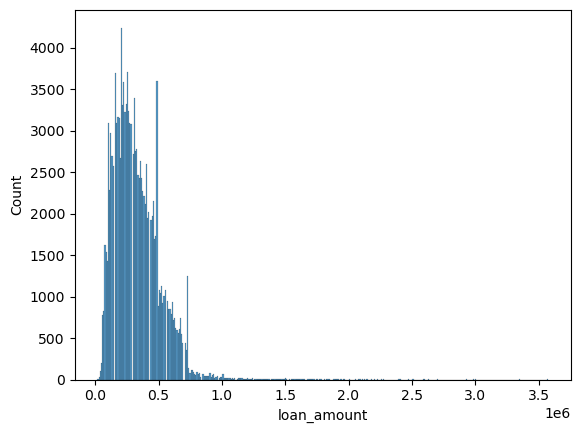

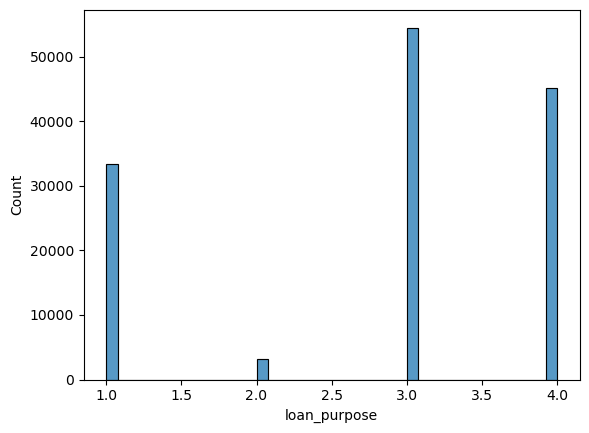

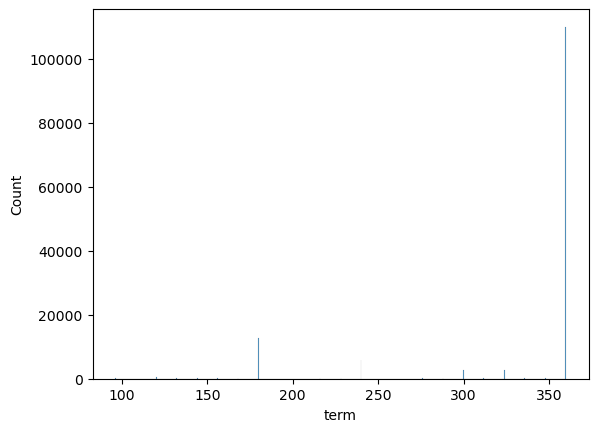

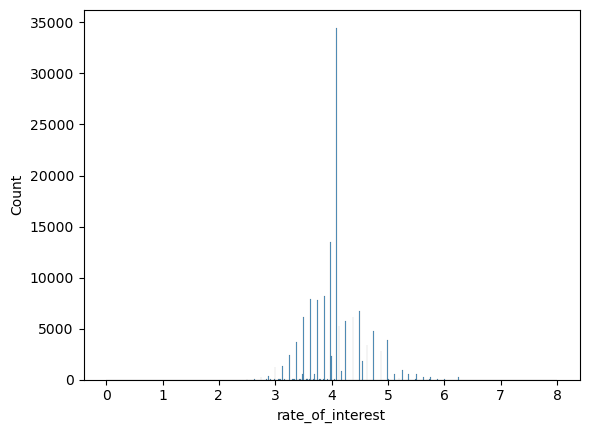

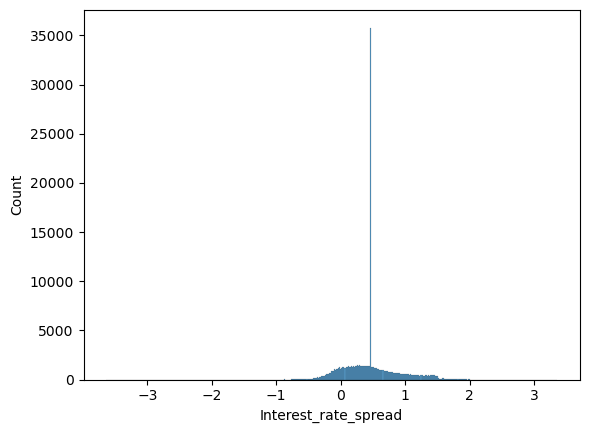

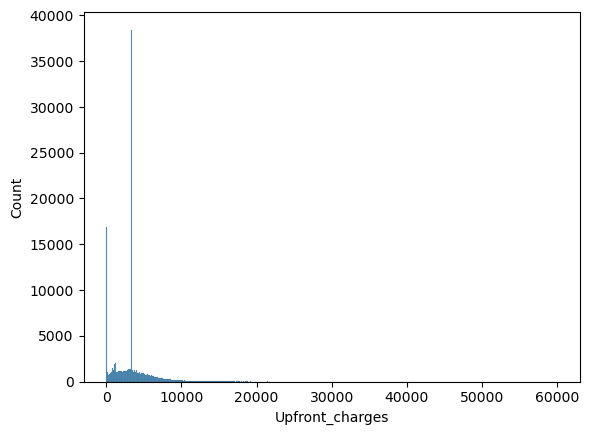

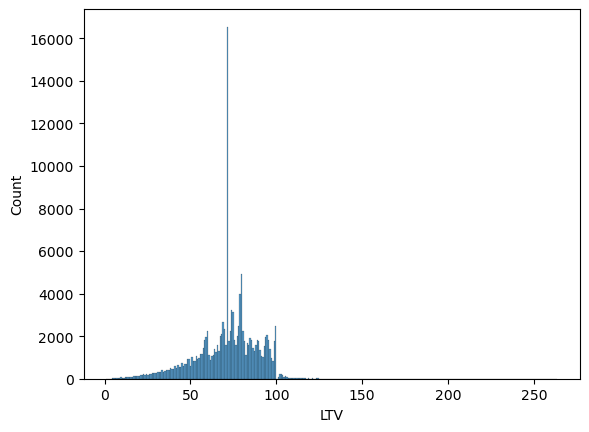

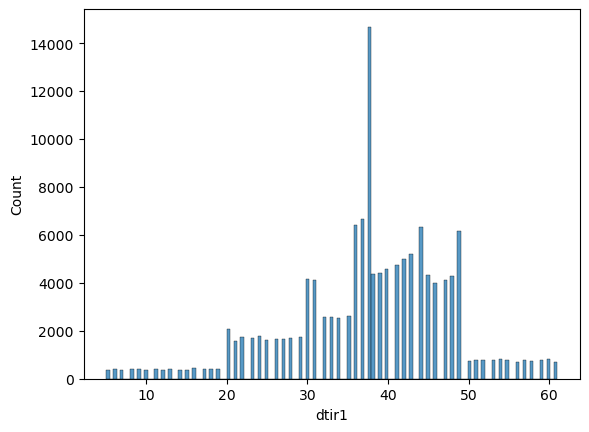

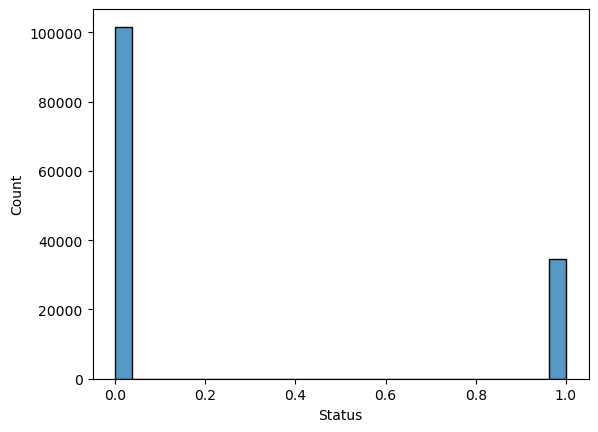

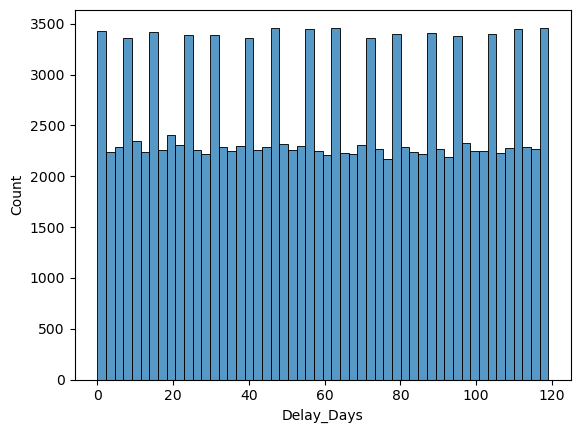

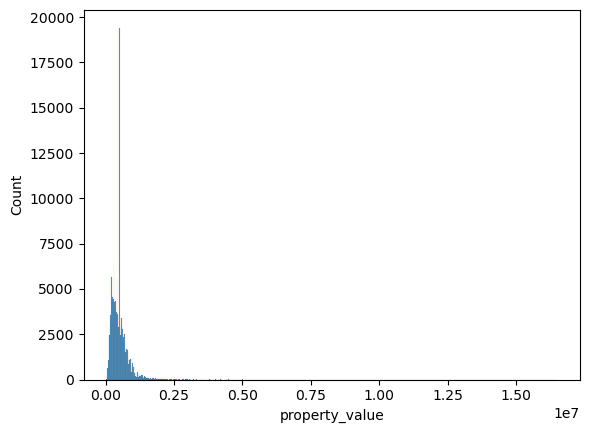

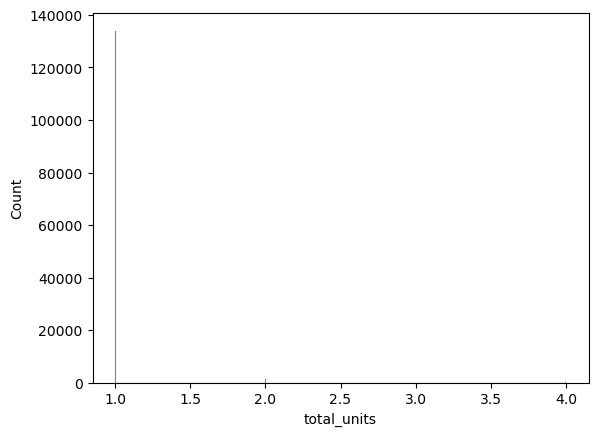

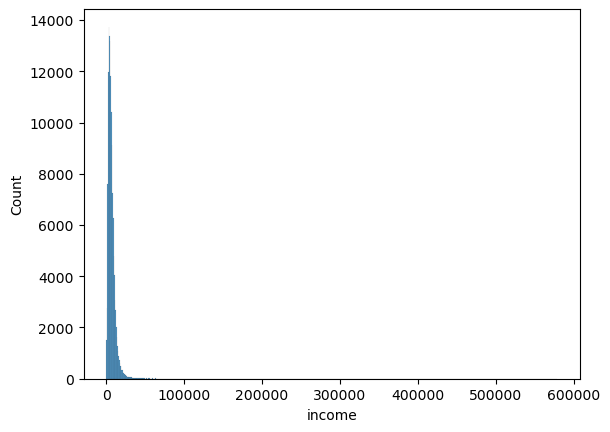

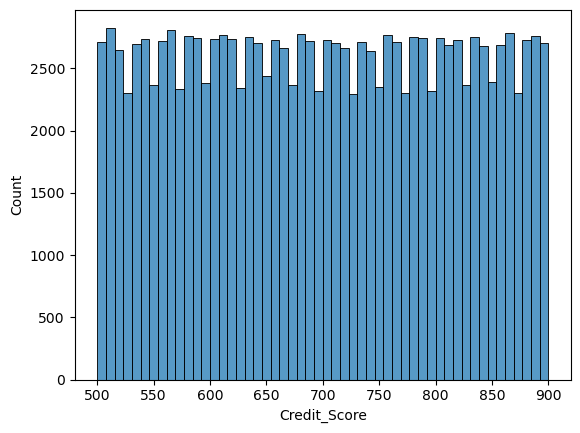

In [38]:
for i in num_cols.columns:
    sns.histplot(x = num_cols[i])
    plt.show()

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from imblearn.over_sampling import ADASYN
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier

In [40]:
cols = text_cols.columns

In [41]:
oe = OrdinalEncoder()
df[cols] = oe.fit_transform(df[cols])

In [42]:
df.head()

,loan_amount,loan_type,loan_purpose,loan_limit,term,rate_of_interest,Interest_rate_spread,Upfront_charges,LTV,dtir1,...,total_units,Security_Type,business_or_commercial,age,income,Gender,Region,credit_type,Credit_Score,co-applicant_credit_type
0,116500,0.0,1,0.0,360.0,4.087372,0.469668,3388.512767,98.728814,45.000000,...,1,1.0,1.0,0.0,1740.0,3.0,3.0,3.0,758,0.0
1,206500,1.0,1,0.0,360.0,4.087372,0.469668,3388.512767,71.465484,37.724782,...,1,1.0,0.0,3.0,4980.0,2.0,0.0,2.0,552,1.0
2,406500,0.0,1,0.0,360.0,4.560000,0.200000,595.000000,80.019685,46.000000,...,1,1.0,1.0,1.0,9480.0,2.0,3.0,3.0,834,0.0
3,456500,0.0,4,0.0,360.0,4.250000,0.681000,3388.512767,69.376900,42.000000,...,1,1.0,1.0,2.0,11880.0,2.0,0.0,3.0,587,0.0
4,696500,0.0,1,0.0,360.0,4.000000,0.304200,0.000000,91.886544,39.000000,...,1,1.0,1.0,0.0,10440.0,1.0,0.0,1.0,602,1.0


In [43]:
x = df.drop(columns= ['Status'])
y = df['Status']

In [44]:
rfc = RandomForestClassifier()
rfc.fit(x,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [45]:
rfc.feature_importances_

array([2.41236605e-03, 2.04782759e-03, 1.16124437e-03, 2.20153873e-04,
       1.70645388e-03, 2.85038912e-01, 3.15916073e-01, 2.64069500e-01,
       2.88250500e-02, 3.07896188e-02, 1.75542452e-04, 1.40470324e-05,
       1.38323474e-02, 1.33375017e-06, 1.97012411e-04, 5.15645692e-06,
       2.21983687e-05, 1.84855745e-05, 1.80785319e-03, 1.89156728e-04,
       4.53149911e-03, 2.28439320e-04, 1.14896525e-04, 4.30720142e-02,
       1.77915850e-04, 3.42490262e-03])

In [46]:
igr = pd.DataFrame()
igr['Features'] = x.columns
igr['Information Gain'] = rfc.feature_importances_
imp = igr.sort_values(by = ['Information Gain'],ascending = True)
imp

,Features,Information Gain
13,construction_type,0.000001
15,Secured_by,0.000005
11,Payment_Status,0.000014
17,Security_Type,0.000018
16,total_units,0.000022
22,Region,0.000115
10,Delay_Days,0.000176
24,Credit_Score,0.000178
19,age,0.000189
14,occupancy_type,0.000197


In [47]:
imp[imp['Information Gain'] > 0.001]

,Features,Information Gain
2,loan_purpose,0.001161
4,term,0.001706
18,business_or_commercial,0.001808
1,loan_type,0.002048
0,loan_amount,0.002412
25,co-applicant_credit_type,0.003425
20,income,0.004531
12,property_value,0.013832
8,LTV,0.028825
9,dtir1,0.030790


In [48]:
selected = imp[imp['Information Gain'] > 0.001]['Features'].tolist()
selected

['loan_purpose',
 'term',
 'business_or_commercial',
 'loan_type',
 'loan_amount',
 'co-applicant_credit_type',
 'income',
 'property_value',
 'LTV',
 'dtir1',
 'credit_type',
 'Upfront_charges',
 'rate_of_interest',
 'Interest_rate_spread']

In [49]:
df_selected = df[selected]

In [50]:
df_selected

,loan_purpose,term,business_or_commercial,loan_type,loan_amount,co-applicant_credit_type,income,property_value,LTV,dtir1,credit_type,Upfront_charges,rate_of_interest,Interest_rate_spread
0,1,360.0,1.0,0.0,116500,0.0,1740.0,118000.000000,98.728814,45.000000,3.0,3388.512767,4.087372,0.469668
1,1,360.0,0.0,1.0,206500,1.0,4980.0,503922.762688,71.465484,37.724782,2.0,3388.512767,4.087372,0.469668
2,1,360.0,1.0,0.0,406500,0.0,9480.0,508000.000000,80.019685,46.000000,3.0,595.000000,4.560000,0.200000
3,4,360.0,1.0,0.0,456500,0.0,11880.0,658000.000000,69.376900,42.000000,3.0,3388.512767,4.250000,0.681000
4,1,360.0,1.0,0.0,696500,1.0,10440.0,758000.000000,91.886544,39.000000,1.0,0.000000,4.000000,0.304200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139474,4,360.0,1.0,0.0,706500,1.0,9840.0,888000.000000,79.560811,36.000000,3.0,878.360000,3.875000,-0.104400
139475,3,180.0,1.0,0.0,296500,0.0,4860.0,408000.000000,72.671569,38.000000,1.0,5566.300000,3.750000,0.420600
139476,3,180.0,1.0,0.0,196500,0.0,8340.0,288000.000000,68.229167,29.000000,3.0,3304.690000,3.990000,0.988800
139477,4,360.0,1.0,0.0,286500,0.0,3420.0,358000.000000,80.027933,40.000000,0.0,3256.880000,3.990000,0.524000


In [51]:
x = df[selected]
x

,loan_purpose,term,business_or_commercial,loan_type,loan_amount,co-applicant_credit_type,income,property_value,LTV,dtir1,credit_type,Upfront_charges,rate_of_interest,Interest_rate_spread
0,1,360.0,1.0,0.0,116500,0.0,1740.0,118000.000000,98.728814,45.000000,3.0,3388.512767,4.087372,0.469668
1,1,360.0,0.0,1.0,206500,1.0,4980.0,503922.762688,71.465484,37.724782,2.0,3388.512767,4.087372,0.469668
2,1,360.0,1.0,0.0,406500,0.0,9480.0,508000.000000,80.019685,46.000000,3.0,595.000000,4.560000,0.200000
3,4,360.0,1.0,0.0,456500,0.0,11880.0,658000.000000,69.376900,42.000000,3.0,3388.512767,4.250000,0.681000
4,1,360.0,1.0,0.0,696500,1.0,10440.0,758000.000000,91.886544,39.000000,1.0,0.000000,4.000000,0.304200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139474,4,360.0,1.0,0.0,706500,1.0,9840.0,888000.000000,79.560811,36.000000,3.0,878.360000,3.875000,-0.104400
139475,3,180.0,1.0,0.0,296500,0.0,4860.0,408000.000000,72.671569,38.000000,1.0,5566.300000,3.750000,0.420600
139476,3,180.0,1.0,0.0,196500,0.0,8340.0,288000.000000,68.229167,29.000000,3.0,3304.690000,3.990000,0.988800
139477,4,360.0,1.0,0.0,286500,0.0,3420.0,358000.000000,80.027933,40.000000,0.0,3256.880000,3.990000,0.524000


In [52]:
sc = StandardScaler()
x = sc.fit_transform(x)

In [53]:
ada = ADASYN()
x_ada,y_ada = ada.fit_resample(x,y)

In [54]:
x_ada.shape

(203779, 14)

In [55]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size = 0.3,random_state = 1)

In [56]:
def build_model(model):
    model.fit(xtrain,ytrain)
    ypred = model.predict(xtest)
    print(f"Training Accuracy : {model.score(xtrain,ytrain)}")
    print(f"Testing Accuracy : {model.score(xtest,ytest)}")
    print(classification_report(ytest,ypred))

In [57]:
build_model(LogisticRegression())

Training Accuracy : 0.7577068004576323
Testing Accuracy : 0.7531837774294671
              precision    recall  f1-score   support

           0       0.76      0.99      0.86     30325
           1       0.66      0.08      0.15     10507

    accuracy                           0.75     40832
   macro avg       0.71      0.53      0.50     40832
weighted avg       0.73      0.75      0.67     40832



In [58]:
build_model(DecisionTreeClassifier())

Training Accuracy : 1.0
Testing Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30325
           1       1.00      1.00      1.00     10507

    accuracy                           1.00     40832
   macro avg       1.00      1.00      1.00     40832
weighted avg       1.00      1.00      1.00     40832



In [59]:
build_model(KNeighborsClassifier())

Training Accuracy : 0.9726470248653868
Testing Accuracy : 0.9579496473354232
              precision    recall  f1-score   support

           0       0.99      0.96      0.97     30325
           1       0.88      0.97      0.92     10507

    accuracy                           0.96     40832
   macro avg       0.93      0.96      0.95     40832
weighted avg       0.96      0.96      0.96     40832



In [60]:
build_model(RandomForestClassifier())

Training Accuracy : 1.0
Testing Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30325
           1       1.00      1.00      1.00     10507

    accuracy                           1.00     40832
   macro avg       1.00      1.00      1.00     40832
weighted avg       1.00      1.00      1.00     40832



In [61]:
build_model(AdaBoostClassifier())

Training Accuracy : 1.0
Testing Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30325
           1       1.00      1.00      1.00     10507

    accuracy                           1.00     40832
   macro avg       1.00      1.00      1.00     40832
weighted avg       1.00      1.00      1.00     40832



In [62]:
build_model(GradientBoostingClassifier())

Training Accuracy : 1.0
Testing Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30325
           1       1.00      1.00      1.00     10507

    accuracy                           1.00     40832
   macro avg       1.00      1.00      1.00     40832
weighted avg       1.00      1.00      1.00     40832



In [63]:
build_model(XGBClassifier())

Training Accuracy : 1.0
Testing Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30325
           1       1.00      1.00      1.00     10507

    accuracy                           1.00     40832
   macro avg       1.00      1.00      1.00     40832
weighted avg       1.00      1.00      1.00     40832



# Final Model

In [64]:
xgb = XGBClassifier()
xgb.fit(xtrain,ytrain)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [65]:
yp = xgb.predict(xtest)

In [66]:
print(classification_report(ytest,yp))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30325
           1       1.00      1.00      1.00     10507

    accuracy                           1.00     40832
   macro avg       1.00      1.00      1.00     40832
weighted avg       1.00      1.00      1.00     40832



In [67]:
xgb.score(xtrain,ytrain),xgb.score(xtest,ytest)

(1.0, 1.0)

In [68]:
import pickle

In [69]:
pickle.dump(xgb,open("model.pkl","wb"))

In [4]:
df.to_csv("loan_data.csv")